In [10]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import Predictive, SVI, Trace_ELBO

def model(data):
    f = numpyro.sample("latent_fairness", dist.Beta(10, 10))
    with numpyro.plate("N", data.shape[0] if data is not None else 10):
        numpyro.sample("obs", dist.Bernoulli(f), obs=data)

def guide(data):
    alpha_q = numpyro.param("alpha_q", 15., constraint=constraints.positive)
    beta_q = numpyro.param("beta_q", 10.,
                           constraint=constraints.positive)
    numpyro.sample("latent_fairness", dist.Beta(alpha_q, beta_q))

data = jnp.concatenate([jnp.ones(60), jnp.zeros(40)])
optimizer = numpyro.optim.Adam(step_size=0.0005)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
state = svi.init(random.PRNGKey(0), data)
num_iterations = 200000
chunk_size = 10000  # Run 10k steps at a time
for i in range(0, num_iterations, chunk_size):
    # Run a chunk of steps
    # We pass the 'state' from the previous chunk into the next one
    svi_result = svi.run(random.PRNGKey(i), chunk_size, data, init_state=state)
    
    # Update the current state to the last state of the chunk
    state = svi_result.state
    
    print(f"Iteration {i + chunk_size}: Loss {svi_result.losses[-1]}")
params = svi_result.params
inferred_mean = params["alpha_q"] / (params["alpha_q"] + params["beta_q"])
# use guide to make predictive
predictive = Predictive(model, guide=guide, params=params, num_samples=1000)
samples = predictive(random.PRNGKey(1), data=None)
# get posterior samples
predictive = Predictive(guide, params=params, num_samples=1000)
posterior_samples = predictive(random.PRNGKey(1), data=None)
# use posterior samples to make predictive
predictive = Predictive(model, posterior_samples, params=params, num_samples=1000)
samples = predictive(random.PRNGKey(1), data=None)

100%|██████████| 10000/10000 [00:00<00:00, 10662.69it/s, init loss: 68.5389, avg. loss [9501-10000]: 69.1878]


Iteration 10000: Loss 69.44668579101562


100%|██████████| 10000/10000 [00:03<00:00, 3320.32it/s, init loss: 67.9605, avg. loss [9501-10000]: 68.8487]


Iteration 20000: Loss 69.69813537597656


100%|██████████| 10000/10000 [00:02<00:00, 3503.26it/s, init loss: 68.0427, avg. loss [9501-10000]: 68.7297]


...

Iteration 180000: Loss 68.52366638183594


100%|██████████| 10000/10000 [00:02<00:00, 3421.37it/s, init loss: 68.5148, avg. loss [9501-10000]: 68.5336]


Iteration 190000: Loss 68.44401550292969


100%|██████████| 10000/10000 [00:03<00:00, 3123.82it/s, init loss: 68.4493, avg. loss [9501-10000]: 68.5342]


Iteration 200000: Loss 68.5240478515625


In [ ]:
inferred_mean

Array(0.5826292, dtype=float32)

: 

AttributeError: 'Predictive' object has no attribute 'mean'

In [2]:
import jax 
import jax.numpy as jnp
import pandas as pd

In [4]:
train = jax.random.normal(jax.random.key(0), (100, 3))
is_cont_africa, ruggedness, log_gdp = train[:, 0], train[:, 1], train[:, 2]

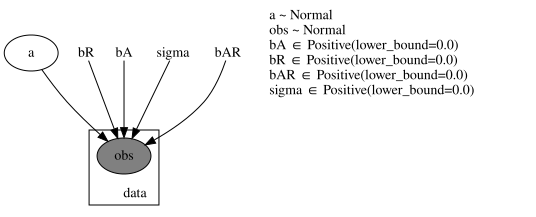

In [ ]:
import numpyro.distributions as dist
import numpyro.distributions.constraints as constraints
import numpyro
def simple_model(is_cont_africa, ruggedness, log_gdp=None):
    a = numpyro.sample("a", dist.Normal(1, 0.5),)
    b_a = numpyro.param("bA", 15., constraint=constraints.positive)
    b_r = numpyro.param("bR", 15., constraint=constraints.positive)
    b_ar = numpyro.param("bAR", 15., constraint=constraints.positive)
    sigma = numpyro.param("sigma", 15., constraint=constraints.positive)

    mean = a + b_a * is_cont_africa + b_r * ruggedness + b_ar * is_cont_africa * ruggedness

    with numpyro.plate("data", len(ruggedness)):
        return numpyro.sample("obs", dist.Normal(mean, sigma), obs=log_gdp)
    
    

numpyro.render_model(simple_model, model_args=(is_cont_africa, ruggedness, log_gdp), render_distributions=True, render_params=True)

In [11]:
conditioned_model = numpyro.handlers.condition(simple_model, data={"obs": log_gdp})

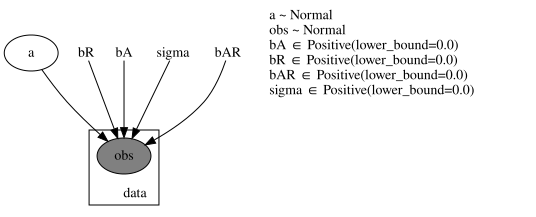

In [14]:
numpyro.render_model(conditioned_model, model_args=(is_cont_africa, ruggedness, log_gdp), render_distributions=True, render_params=True)